<a href="https://colab.research.google.com/github/wahiwatkar06-gif/mdm-practicals/blob/main/Practical_No_8_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import dendrogram, linkage

In [ ]:
file = "wireless_signal_hierarchical_dataset.csv"

In [ ]:
import pandas as pd

# Load the dataset first
data = pd.read_csv(file)

if len(data.columns) == 1:
  print("Signal column detected. Fixing CSV format...")
  data = data.iloc[:,0].str.split(
      ",", expand=True
  )

In [ ]:
data.colomns = [
    "RSSI",
    "RSRP",
    "RSRQ",
    "Latency",
    "Packet_Loss"
]

/tmp/ipykernel_1958/3467637347.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  data.colomns = [


In [ ]:
print("\nDataset Preview:")
print(data.head())

print("\nDataset Columns:")
print(data.columns)



Dataset Preview:
    RSSI   RSRP  RSRQ   SNR  Latency  Packet_Loss
0  -53.8  -81.1  -5.4  21.6     18.3          3.5
1  -94.5 -105.6 -20.3   3.9    137.3         14.1
2  -58.9  -70.1  -9.0  22.2     21.8          0.2
3  -82.4 -100.3 -15.1   4.3     92.0         16.5
4 -103.8 -110.7 -16.4  -4.9    103.5         12.5

Dataset Columns:
Index(['RSSI', 'RSRP', 'RSRQ', 'SNR', 'Latency', 'Packet_Loss'], dtype='object')


In [ ]:
for col in data.columns:

    data[col] = pd.to_numeric(
        data[col],
        errors="coerce"
    )

data.dropna(inplace=True)

print("\nMissing Values:")
print(data.isnull().sum())


Missing Values:
RSSI           0
RSRP           0
RSRQ           0
SNR            0
Latency        0
Packet_Loss    0
dtype: int64


In [ ]:
X = data[
    [
        "RSSI",
        "RSRP",
        "RSRQ",
        "SNR",
        "Latency",
        "Packet_Loss"
    ]
]


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

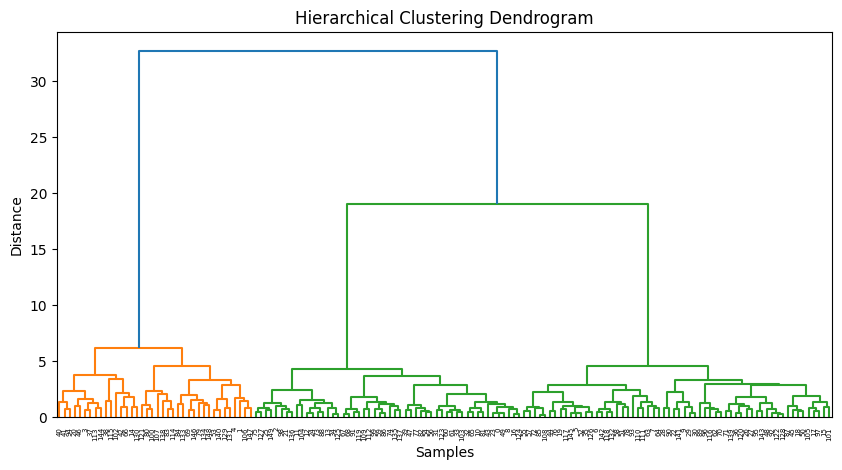

In [ ]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

plt.figure(figsize=(10, 5))

linked = linkage(
    X_scaled,
    method="ward"
)

dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")

plt.show()

In [ ]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

data["Cluster"] = model.fit_predict(X_scaled)
print("\nCluster Count:")

print(
    data["Cluster"].value_counts()
)


Cluster Count:
Cluster
1    60
2    52
0    38
Name: count, dtype: int64


In [ ]:
cluster_rssi = data.groupby(
    "Cluster"
)["RSSI"].mean()

print("\nAverage RSSI:")

print(cluster_rssi)


Average RSSI:
Cluster
0   -88.257895
1   -70.630000
2   -55.405769
Name: RSSI, dtype: float64


In [ ]:
sorted_clusters = cluster_rssi.sort_values(
    ascending=False
)

quality = {

    sorted_clusters.index[0]: "Good",

    sorted_clusters.index[1]: "Medium",

    sorted_clusters.index[2]: "Poor"
}

data["Signal_Quality"] = data["Cluster"].map(
    quality
)

In [ ]:
print("\nFinal Classification:")

print(
    data[
        [
            "RSSI",
            "RSRP",
            "SNR",
            "Cluster",
            "Signal_Quality"
        ]
    ]
)


Final Classification:
      RSSI   RSRP   SNR  Cluster Signal_Quality
0    -53.8  -81.1  21.6        2           Good
1    -94.5 -105.6   3.9        0           Poor
2    -58.9  -70.1  22.2        2           Good
3    -82.4 -100.3   4.3        0           Poor
4   -103.8 -110.7  -4.9        0           Poor
..     ...    ...   ...      ...            ...
145  -72.9  -96.6  13.2        1         Medium
146  -93.6 -114.1   4.0        0           Poor
147  -92.6 -107.3  -3.4        0           Poor
148  -89.5 -110.7   0.9        0           Poor
149  -56.8  -81.6  20.7        2           Good

[150 rows x 5 columns]


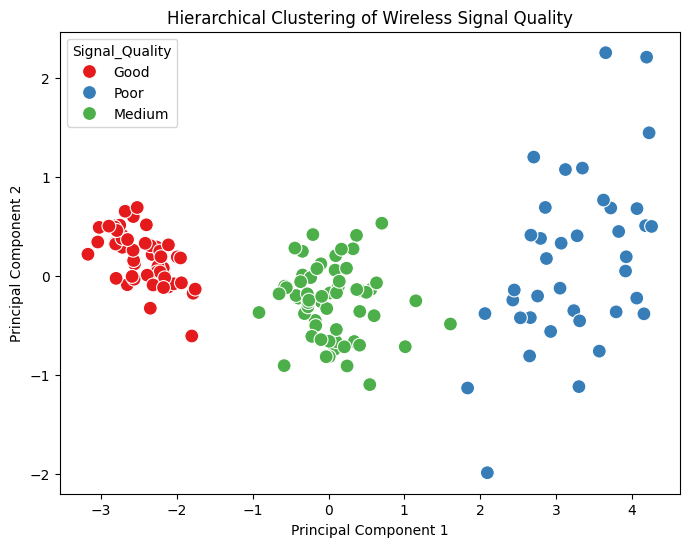

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)


plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=data["Signal_Quality"],
    palette="Set1",
    s=100
)

plt.title(
    "Hierarchical Clustering of Wireless Signal Quality"
)

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.show()